# Assignment 2: From Trees to Neural Networks
## Bank Marketing Dataset - Term Deposit Prediction

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.impute import KNNImputer, SimpleImputer
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


## Load Dataset

In [2]:
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

data = pd.concat([X, y], axis=1)

print(f'Dataset shape: {data.shape}')
print(data.head())

Dataset shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  


## Data Preprocessing

In [3]:
print(f'Count:')
print(data['y'].value_counts())
print('\n\n')

print('mising vals:')
print(data.isnull().sum())

# drop cols with >70% missing
missing_threshold = 0.7
missing_percent = data.isnull().mean()
cols_to_drop = missing_percent[missing_percent > missing_threshold].index
data.drop(columns=cols_to_drop, inplace=True)

Count:
y
no     39922
yes     5289
Name: count, dtype: int64



mising vals:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


## Data Preprocessing

In [4]:
# Separate features and target
df = data.copy()
df['y'] = (df['y'] == 'yes').astype(int)

X = df.drop('y', axis=1)
y = df['y']

# Split data first (70/15/15) to prevent data leakage
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(f'Train set: {X_train.shape}, {y_train.value_counts().to_dict()}')
print(f'Validation set: {X_val.shape}, {y_val.value_counts().to_dict()}')
print(f'Test set: {X_test.shape}, {y_test.value_counts().to_dict()}')
print(f'\nMissing values in train: {X_train.isnull().sum().sum()}')

# Identify numeric and categorical columns
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Standardize numerical features (fit on train, transform on val/test)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Impute missing values with KNN (only on numerical columns)
imputer = KNNImputer(n_neighbors=5)
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = imputer.transform(X_val[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

# Impute categorical with mode
cat_imputer = SimpleImputer(strategy='most_frequent')

if len(cat_cols) > 0:
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# One-hot encode categorical features
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Align columns (ensure val/test have same columns as train)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f'\nAfter preprocessing:')
print(f'Train: {X_train.shape}, missing: {X_train.isnull().sum().sum()}')
print(f'Val: {X_val.shape}, missing: {X_val.isnull().sum().sum()}')
print(f'Test: {X_test.shape}, missing: {X_test.isnull().sum().sum()}')
print(f'Total features after one-hot encoding: {X_train.shape[1]}')

# Apply SMOTE to balance the training data
print('\nApplying SMOTE to balance training data...')
print(f'Before SMOTE - Train: {y_train.value_counts().to_dict()}')

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f'After SMOTE - Train: {y_train.value_counts().to_dict()}')
print(f'Training set size increased from {len(X_train)} to {len(X_train)} samples')

# Keep original data for comparison
X_train_original = X_train.copy()
y_train_original = y_train.copy()


Train set: (31647, 15), {0: 27945, 1: 3702}
Validation set: (6782, 15), {0: 5988, 1: 794}
Test set: (6782, 15), {0: 5989, 1: 793}

Missing values in train: 10620

After preprocessing:
Train: (31647, 36), missing: 0
Val: (6782, 36), missing: 0
Test: (6782, 36), missing: 0
Total features after one-hot encoding: 36

Applying SMOTE to balance training data...
Before SMOTE - Train: {0: 27945, 1: 3702}
After SMOTE - Train: {0: 27945, 1: 27945}
Training set size increased from 55890 to 55890 samples


In [5]:
DEFAULT_PARAMS = dict(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=5,
    subsample=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=10
)

def sweep_param(param_name, values):
    results = []
    for v in values:
        params = {**DEFAULT_PARAMS, param_name: v}
        model = xgb.XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )
        y_pred = model.predict(X_val)
        results.append({
            param_name: v,
            'accuracy': accuracy_score(y_val, y_pred),
            'f1': f1_score(y_val, y_pred),
        })
    return pd.DataFrame(results)

# --- sweeps ---
sweeps = {
    'learning_rate': [0.01, 0.05, 0.1, 0.25, 0.3, 0.5],
    'n_estimators':  [50, 100, 200, 300, 500, 1000],
    'max_depth':     [3, 5, 7, 9, 11, 15],
    'subsample':     [0.1, 0.5, 0.6, 0.8, 1.0],
    'reg_alpha':     [0, 0.01, 0.1, 0.5, 1, 5],
    'reg_lambda':    [0, 0.1, 0.5, 1, 2, 5, 10],
}

for param, values in sweeps.items():
    print(f"\n--- {param} ---")
    df = sweep_param(param, values)
    print(df)


--- learning_rate ---
   learning_rate  accuracy        f1
0           0.01  0.825568  0.521634
1           0.05  0.860513  0.560817
2           0.10  0.878354  0.581006
3           0.25  0.897081  0.579011
4           0.30  0.899440  0.576398
5           0.50  0.902684  0.576380

--- n_estimators ---
   n_estimators  accuracy        f1
0            50  0.861545  0.561010
1           100  0.878354  0.581006
2           200  0.893099  0.584527
3           300  0.898555  0.573730
4           500  0.901209  0.572158
5          1000  0.901209  0.572158

--- max_depth ---
   max_depth  accuracy        f1
0          3  0.869360  0.579297
1          5  0.878354  0.581006
2          7  0.889708  0.585366
3          9  0.894721  0.581477
4         11  0.897228  0.574221
5         15  0.899440  0.576398

--- subsample ---
   subsample  accuracy        f1
0        0.1  0.881156  0.587090
1        0.5  0.884990  0.596691
2        0.6  0.880566  0.585466
3        0.8  0.878354  0.581006
4        1

In [6]:
param_distributions = {
    'learning_rate': uniform(0.01, 0.7),
    'max_depth': randint(3, 21),
    'n_estimators': randint(100, 501), 
    'subsample': uniform(0.6, 1.0), 
    'reg_alpha': uniform(0, 2), 
    'reg_lambda': uniform(0.5, 2)  
}

xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions,
    n_iter=300, 
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print('Running random search...')
random_search.fit(X_train, y_train)

print(f'\nBest parameters: {random_search.best_params_}')
print(f'Best cross-validation F1 score: {random_search.best_score_:.4f}')

Running random search...
Fitting 5 folds for each of 300 candidates, totalling 1500 fits

Best parameters: {'learning_rate': np.float64(0.07273843740845948), 'max_depth': 20, 'n_estimators': 101, 'reg_alpha': np.float64(0.5452480014670675), 'reg_lambda': np.float64(1.327098203050703), 'subsample': np.float64(0.7218860933369475)}
Best cross-validation F1 score: 0.9327


In [7]:
# Train final XGBoost model with best parameters
xgb_best = random_search.best_estimator_

# Retrain with early stopping and scale_pos_weight
xgb_final = xgb.XGBClassifier(
    **random_search.best_params_, 
    random_state=42, 
    eval_metric='logloss', 
    early_stopping_rounds=20
)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

### XGBoost Evaluation

In [8]:
# Evaluate on test set
y_pred_xgb = xgb_final.predict(X_test)
y_pred_xgb_proba = xgb_final.predict_proba(X_test)[:, 1]

# Calculate metrics
precision, recall, _ = precision_recall_curve(y_test, y_pred_xgb_proba)
auc_pr_xgb = auc(recall, precision)

xgb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_pred_xgb_proba),
    'AUC-PR': auc_pr_xgb
}

print('XGBoost res:')
for metric, value in xgb_metrics.items():
    print(f'{metric}: {value:.4f}')

print(classification_report(y_test, y_pred_xgb))

XGBoost res:
Accuracy: 0.8916
Precision: 0.5338
Recall: 0.5776
F1-Score: 0.5548
ROC-AUC: 0.9057
AUC-PR: 0.5089
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      5989
           1       0.53      0.58      0.55       793

    accuracy                           0.89      6782
   macro avg       0.74      0.76      0.75      6782
weighted avg       0.90      0.89      0.89      6782




Top 15 Most Important Features:
    feature  importance
  month_mar    0.113318
  month_oct    0.090607
housing_yes    0.067289
   duration    0.066816
   previous    0.056790
   campaign    0.056128
  month_dec    0.047810
  month_sep    0.043340
  month_feb    0.040214
      pdays    0.033561
job_student    0.031892
  month_jan    0.023167
  month_may    0.022357
  month_nov    0.021536
  month_aug    0.018841


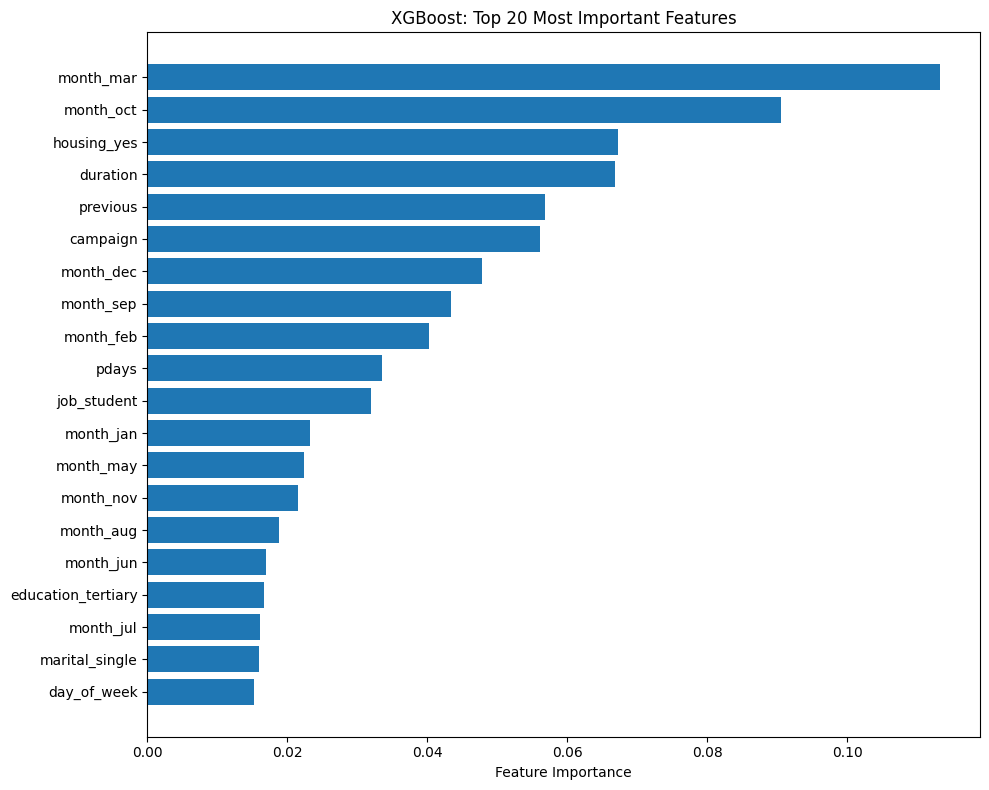

In [ ]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)

print('\nTop 15 Most Important Features:')
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('XGBoost: Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Explore Network Architecture

In [ ]:
DEFAULT_MLP_PARAMS = dict(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

def sweep_mlp_param(param_name, values):
    results = []
    for v in values:
        params = {**DEFAULT_MLP_PARAMS, param_name: v}
        model = MLPClassifier(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        results.append({
            param_name: str(v), 
            'accuracy': accuracy_score(y_val, y_pred),
            'f1': f1_score(y_val, y_pred),
            'iterations': model.n_iter_,
        })
    return pd.DataFrame(results)

# --- sweeps ---
mlp_sweeps = {
    'hidden_layer_sizes': [
        (64,),
        (128,),
        (128, 64),
        (256, 128),
        (256, 128, 64),
        (512, 256, 128),
    ],
    'activation': ['relu', 'tanh', 'logistic'],
    'learning_rate_init': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [50, 100, 200, 500, 1000],
}

for param, values in mlp_sweeps.items():
    print(f"\n--- {param} ---")
    df = sweep_mlp_param(param, values)
    print(df)


--- hidden_layer_sizes ---
  hidden_layer_sizes  accuracy        f1  iterations
0              (64,)  0.856237  0.540311          67
1             (128,)  0.869508  0.559920          59
2          (128, 64)  0.869802  0.530569          63
3         (256, 128)  0.875258  0.495828          75
4     (256, 128, 64)  0.872162  0.486679          68
5    (512, 256, 128)  0.881893  0.495274          75

--- activation ---
  activation  accuracy        f1  iterations
0       relu  0.869802  0.530569          63
1       tanh  0.874078  0.512557         112
2   logistic  0.822324  0.508364          21

--- learning_rate_init ---
  learning_rate_init  accuracy        f1  iterations
0             0.0001  0.874226  0.571141         119
1              0.001  0.869802  0.530569          63
2               0.01  0.872751  0.528673          39
3                0.1  0.838543  0.540881          30

--- max_iter ---
  max_iter  accuracy        f1  iterations
0       50  0.873489  0.519058          50
1   

### Effect of Network Depth and Width on Validation Performance

In [ ]:
# Systematic analysis of depth and width effects
print("Analyzing effect of network depth and width on validation performance...\n")

# 1. width
width_configs = [
    (32,), (64,), (128,), (256,), (512,), (1024,)
]

# depth
depth_configs = [
    (256,),              # 1 layer
    (256, 128),          # 2 layers
    (256, 128, 64),      # 3 layers
    (256, 128, 64, 32),  # 4 layers
    (256, 128, 64, 32, 16)  # 5 layers
]

def evaluate_architecture(arch, max_iter=200):
    """Train and evaluate a single architecture"""
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        learning_rate_init=0.001,
        alpha=0.0001,
        max_iter=max_iter,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        verbose=False
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    # Calculate total parameters
    total_params = sum(p * q for p, q in zip([X_train.shape[1]] + list(arch), list(arch) + [2]))
    
    return {
        'architecture': str(arch),
        'depth': len(arch),
        'width': arch[0] if len(arch) > 0 else 0,
        'total_params': total_params,
        'accuracy': accuracy_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'iterations': model.n_iter_
    }

# Evaluate width configurations
print("Testing different network widths...")
width_results = []
for arch in width_configs:
    result = evaluate_architecture(arch)
    width_results.append(result)
    print(f"  {arch}: F1={result['f1']:.4f}, Acc={result['accuracy']:.4f}")

# Evaluate depth configurations
print("\nTesting different network depths...")
depth_results = []
for arch in depth_configs:
    result = evaluate_architecture(arch)
    depth_results.append(result)
    print(f"  {arch}: F1={result['f1']:.4f}, Acc={result['accuracy']:.4f}")

width_df = pd.DataFrame(width_results)
depth_df = pd.DataFrame(depth_results)

Analyzing effect of network depth and width on validation performance...

Testing different network widths...
  (32,): F1=0.5640, Acc=0.8618
  (64,): F1=0.5403, Acc=0.8562
  (128,): F1=0.5599, Acc=0.8695
  (256,): F1=0.5596, Acc=0.8828
  (512,): F1=0.5161, Acc=0.8717
  (1024,): F1=0.5275, Acc=0.8795

Testing different network depths...
  (256,): F1=0.5596, Acc=0.8828
  (256, 128): F1=0.4958, Acc=0.8753
  (256, 128, 64): F1=0.4867, Acc=0.8722
  (256, 128, 64, 32): F1=0.5125, Acc=0.8701
  (256, 128, 64, 32, 16): F1=0.5151, Acc=0.8795


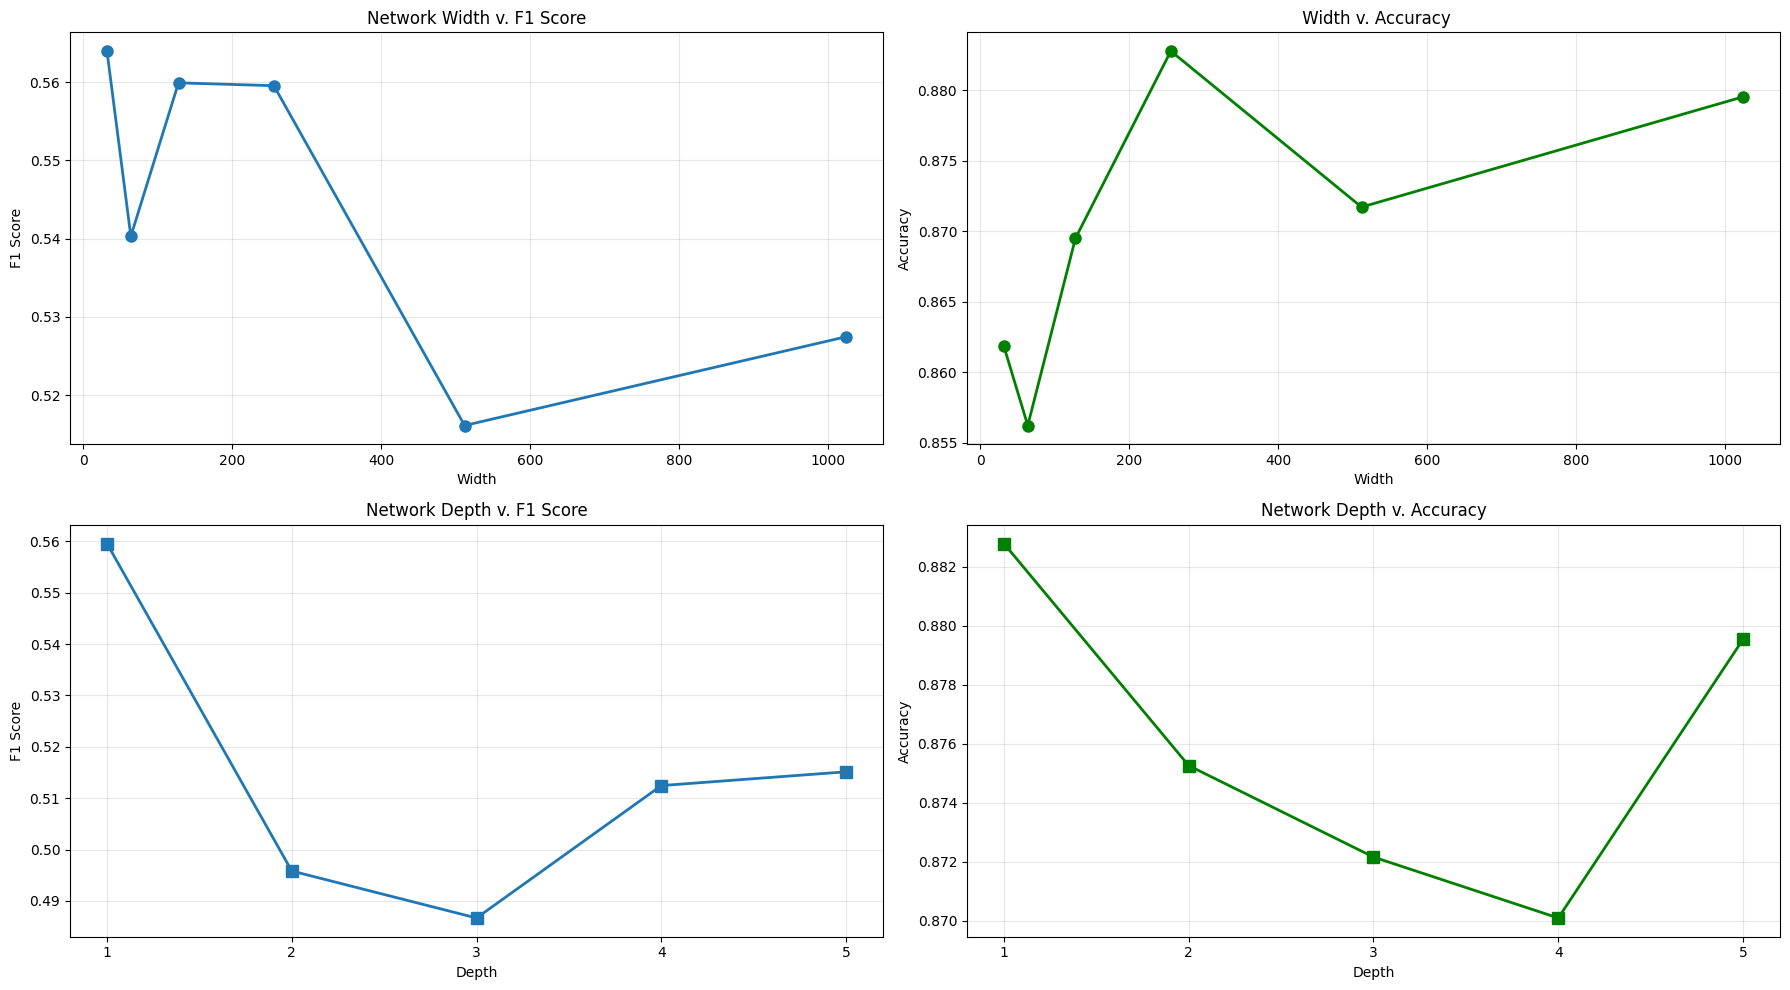

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Width analysis
axes[0, 0].plot(width_df['width'], width_df['f1'], marker='o', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Width')
axes[0, 0].set_ylabel('F1 Score')
axes[0, 0].set_title('Network Width v. F1 Score')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(width_df['width'], width_df['accuracy'], marker='o', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Width')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title(' Width v. Accuracy')
axes[0, 1].grid(True, alpha=0.3)

# depth analysis
axes[1, 0].plot(depth_df['depth'], depth_df['f1'], marker='s', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Depth')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Network Depth v. F1 Score')
axes[1, 0].set_xticks(depth_df['depth'])
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(depth_df['depth'], depth_df['accuracy'], marker='s', linewidth=2, markersize=8, color='green')
axes[1, 1].set_xlabel('Depth')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Network Depth v. Accuracy')
axes[1, 1].set_xticks(depth_df['depth'])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Grid search for MLP
param_grid_mlp = {
    'hidden_layer_sizes': [(128, 64), (256, 128), (256, 128, 64), (256, 128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.1, 0.25],
    'alpha': [0.0001, 0.001, 0.01] 
}

mlp_model = MLPClassifier(
    random_state=42,
    max_iter=200,
    early_stopping=True
)

grid_search_mlp = GridSearchCV(
    mlp_model,
    param_grid_mlp,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print('Running MLP grid search...')
grid_search_mlp.fit(X_train, y_train)

print(f'\nBest parameters: {grid_search_mlp.best_params_}')
print(f'Best cross-validation F1 score: {grid_search_mlp.best_score_:.4f}')

Running MLP grid search...
Fitting 3 folds for each of 96 candidates, totalling 288 fits

Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001}
Best cross-validation F1 score: 0.9251


In [21]:
# Train final MLP with best parameters
mlp_final = grid_search_mlp.best_estimator_

print('Final MLP model training complete')
print(f'Number of iterations: {mlp_final.n_iter_}')
print(f'Final loss: {mlp_final.loss_:.6f}')

Final MLP model training complete
Number of iterations: 68
Final loss: 0.032170


In [29]:
# Evaluate on test set
y_pred_mlp = mlp_final.predict(X_test)
y_pred_mlp_proba = mlp_final.predict_proba(X_test)[:, 1]

# Calculate metrics
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_pred_mlp_proba)
auc_pr_mlp = auc(recall_mlp, precision_mlp)

mlp_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall': recall_score(y_test, y_pred_mlp),
    'F1-Score': f1_score(y_test, y_pred_mlp),
    'ROC-AUC': roc_auc_score(y_test, y_pred_mlp_proba),
    'AUC-PR': auc_pr_mlp
}

print('MLP Test Set Results:')
for metric, value in mlp_metrics.items():
    print(f'{metric}: {value:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlp))

MLP Test Set Results:
Accuracy: 0.8710
Precision: 0.4540
Recall: 0.5107
F1-Score: 0.4807
ROC-AUC: 0.8684
AUC-PR: 0.4389

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      5989
           1       0.45      0.51      0.48       793

    accuracy                           0.87      6782
   macro avg       0.69      0.71      0.70      6782
weighted avg       0.88      0.87      0.87      6782



### MLP Training Curve

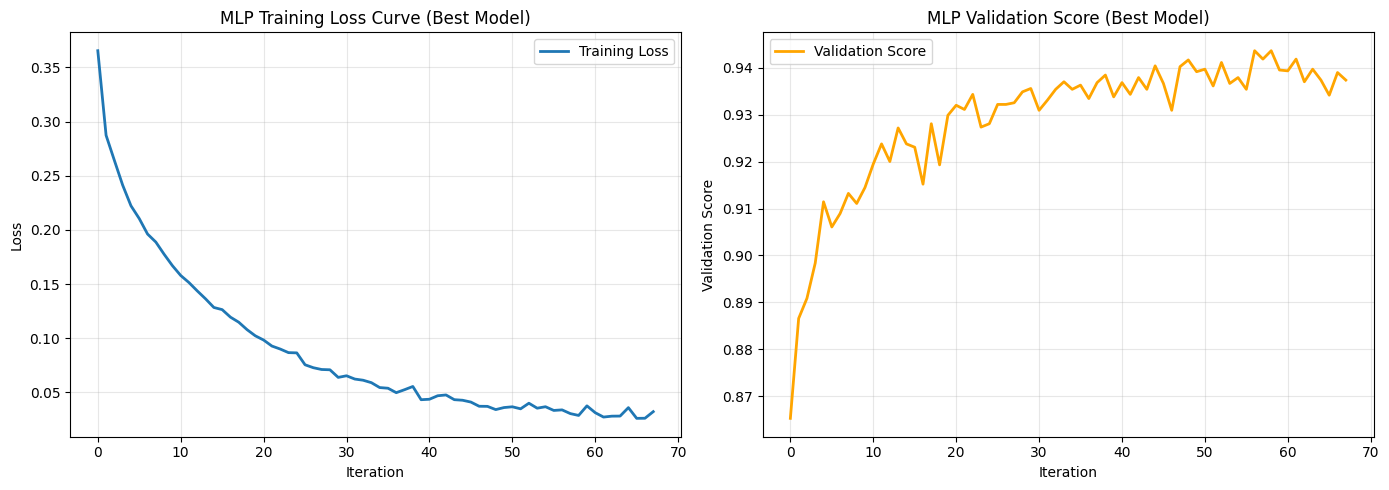

Note: MLP stopped at iteration 68 (early stopping)


In [ ]:
# Plot MLP training curve (training loss only - MLP doesn't store validation loss separately)
# Note: MLP uses early_stopping on validation but only stores training loss curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MLP Training Loss
axes[0].plot(mlp_final.loss_curve_, label='Training Loss', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('MLP Training Loss Curve (Best Model)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MLP Validation Scores (F1) - need to retrain with verbose tracking
axes[1].plot(mlp_final.validation_scores_ if hasattr(mlp_final, 'validation_scores_') else [], 
             label='Validation Score', linewidth=2, color='orange')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Validation Score')
axes[1].set_title('MLP Validation Score (Best Model)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Note: MLP stopped at iteration {mlp_final.n_iter_} (early stopping)')

## GBDT vs MLP Comparison

### Training Time Comparison

In [23]:
import time

# Measure XGBoost training time
start_time = time.time()
xgb_time_model = xgb.XGBClassifier(**random_search.best_params_, random_state=42, eval_metric='logloss')
xgb_time_model.fit(X_train, y_train)
xgb_training_time = time.time() - start_time

# Measure MLP training time
start_time = time.time()
mlp_time_model = MLPClassifier(**grid_search_mlp.best_params_, random_state=42, max_iter=200, early_stopping=True)
mlp_time_model.fit(X_train, y_train)
mlp_training_time = time.time() - start_time

print('\n=== Training Time Comparison ===')
print(f'XGBoost time: {xgb_training_time:.2f} seconds')
print(f'MLP time: {mlp_training_time:.2f} seconds')
print(f'Ratio (MLP/XGBoost): {mlp_training_time/xgb_training_time:.2f}x')


=== Training Time Comparison ===
XGBoost time: 1.51 seconds
MLP time: 26.63 seconds
Ratio (MLP/XGBoost): 17.68x


### Confusion Matrices

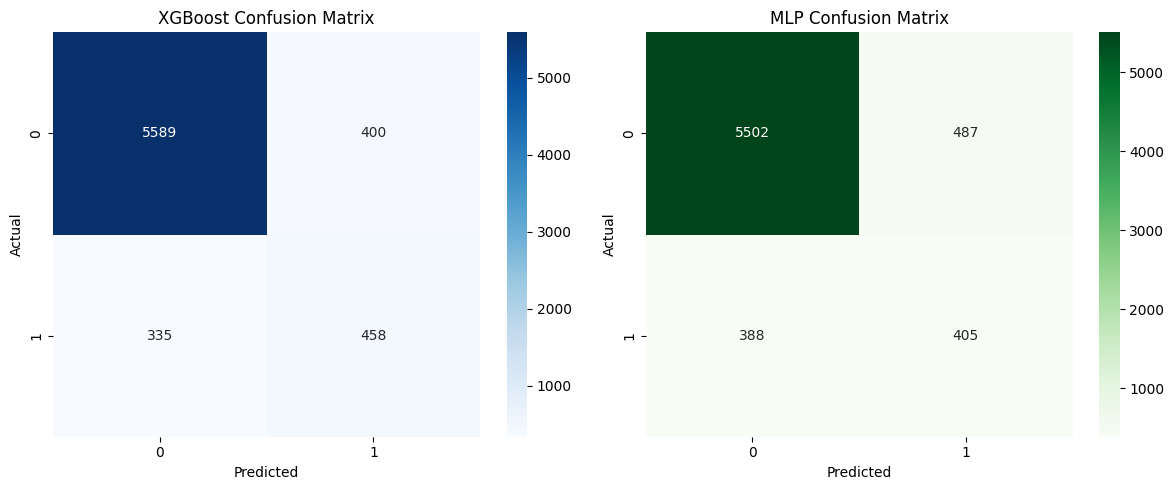

In [31]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# MLP confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('MLP Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### ROC and Precision-Recall Curves

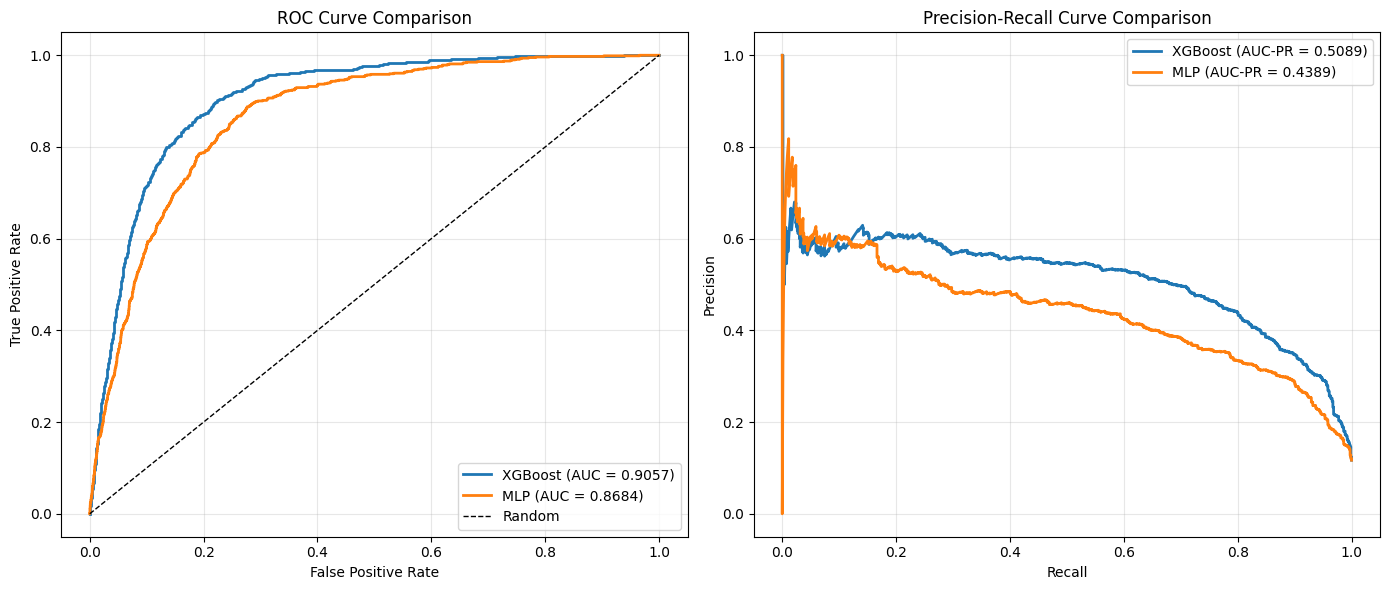

In [30]:
from sklearn.metrics import roc_curve

# Plot ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb_proba)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp_proba)

axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_metrics["ROC-AUC"]:.4f})', linewidth=2)
axes[0].plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {mlp_metrics["ROC-AUC"]:.4f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall, precision, label=f'XGBoost (AUC-PR = {auc_pr_xgb:.4f})', linewidth=2)
axes[1].plot(recall_mlp, precision_mlp, label=f'MLP (AUC-PR = {auc_pr_mlp:.4f})', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()